In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
#read the raw data
df = pd.read_csv("TMDB_movie_dataset_v11.csv")

In [3]:
#only keep useful information
df = df[["id", "revenue", "status", "release_date", "genres", "production_companies"]]
df = df[df["status"] == "Released"]
df = df.dropna(subset=["production_companies", "genres", "release_date"], how="any")

In [4]:
#select data between 1920 to 2023
df = df[df["revenue"] != 0]
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df[(df["release_date"].dt.year >= 1920) & (df["release_date"].dt.year <= 2023)]
df["year"] = df["release_date"].dt.year

In [5]:
df.shape

(16634, 7)

In [6]:
#keep the first genre as main genre
df["main_genre"] = df["genres"].str.split(",").str[0].str.strip()

In [9]:
df.head(5)

,id,revenue,status,release_date,genres,production_companies,year,main_genre,decade
1238420,848091,200000,Released,1920-02-14,Drama,Selznick Pictures Corporation,1920,Drama,1920
3030,234,8811,Released,1920-02-27,"Drama, Horror, Thriller, Crime",Decla Film Gesellschaft Holz & Co.,1920,Drama,1920
1238422,848094,200,Released,1920-03-08,Drama,Selznick Pictures Corporation,1920,Drama,1920
20024,31509,4500000,Released,1920-09-03,"Drama, Action, Romance","D.W. Griffith Productions, United Artists",1920,Drama,1920
815701,563505,3000000,Released,1920-09-17,"Drama, Crime",Fox Film Corporation,1920,Drama,1920


In [10]:
#sort the date by release_date
df = df.sort_values(by="release_date")
#classify the data into decades
df["decade"] = (df["year"] // 10) * 10
#count the total number of films of each genre per decade 
decade_genre_counts = df.groupby(["decade", "main_genre"]).size().reset_index(name="count")

In [12]:
#give a label to each film indicate that if the film is the top genre of the decade
top_genre_per_decade = decade_genre_counts.loc[
    decade_genre_counts.groupby("decade")["count"].idxmax()
].set_index("decade")["main_genre"]
df["is_top_genre"] = df.apply(
    lambda row: row["main_genre"] == top_genre_per_decade.get(row["decade"]),
    axis=1
)

In [13]:
top_genre_per_decade

decade
1920     Drama
1930     Drama
1940     Drama
1950     Drama
1960     Drama
1970     Drama
1980    Comedy
1990    Comedy
2000     Drama
2010     Drama
2020     Drama
Name: main_genre, dtype: object

In [14]:
#add a label indicate that if the major prodution company is one of the production companies
major_companies = [
    "20th Century Fox",
    "Warner Bros. Pictures",
    "Universal Pictures",
    "Walt Disney Pictures",
    "Columbia Pictures",
    "Paramount"
]
df["is_major_company"] = df["production_companies"].apply(
    lambda x: any(company in str(x) for company in major_companies)
)

In [15]:
df = df[["id", "revenue", "main_genre", "decade", "is_top_genre", "is_major_company"]]

Data Visualization

<Axes: xlabel='is_top_genre', ylabel='revenue'>

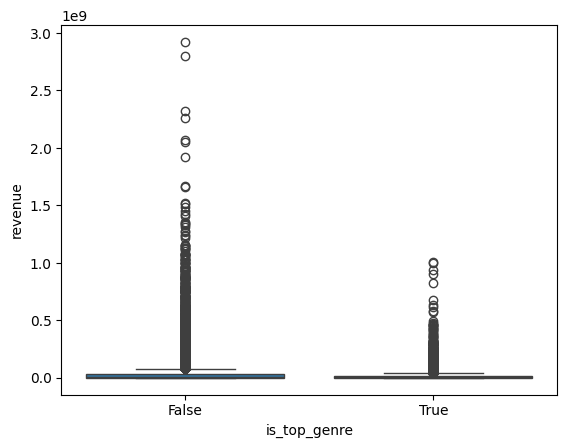

In [16]:
sns.boxplot(data=df, x="is_top_genre", y="revenue")

<Axes: xlabel='is_major_company', ylabel='revenue'>

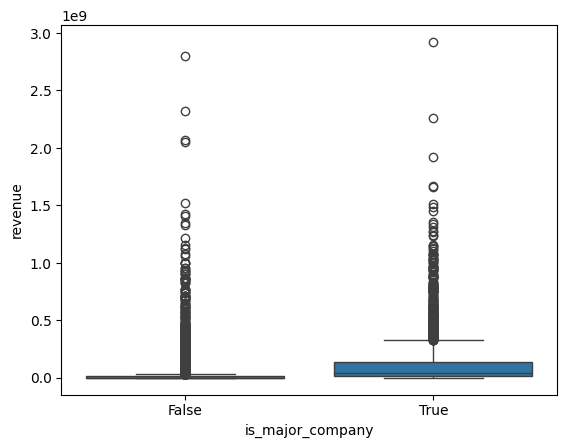

In [17]:
sns.boxplot(data=df, x="is_major_company", y="revenue")

<Axes: xlabel='is_top_genre', ylabel='is_major_company'>

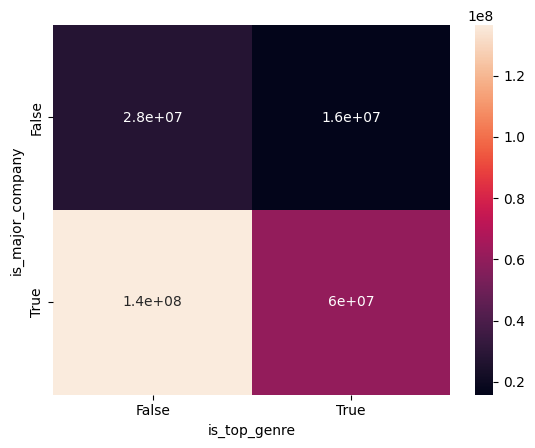

In [18]:
pivot = df.pivot_table(
    index="is_major_company",
    columns="is_top_genre",
    values="revenue",
    aggfunc="mean"
)
sns.heatmap(pivot, annot=True)

In [19]:
df.to_csv("film.csv", index=False)